# FEATURE ENGINEERING


---

### **Feature Engineering Overview**

* **Goal:** Transform raw data into features that make the model perform better.
* **Why:** To improve predictive performance, reduce computation/data needs, and make results easier to interpret.
* **Key idea:** Transformations you apply become part of the model’s learning aty.

---

### **Course Focus**

You’ll learn to:

1. Find important features with **mutual information**.
2. **Create new features** from existing ones.
3. **Encode high-cardinality categories** with target encoding.
4. Make **segmentation features** with k-means clustering.
5. Reduce data dimensions with **PCA**.

---

### **Example:**

* Predicting **price** from **length** doesn’t work well for a linear model because the relationship is curved.
* Squaring length to get **area** creates a **linear relationship**, allowing the linear model to perform much better.

---

### **Guiding Principle**

* A feature is useful only if it has a **learnable relationship** with the target.
* If your model can’t learn a relationship directly, you can create transformed featand the guiding principle on one page.


## Concrete Formulations

#### To illustrate these ideas we'll see how adding a few synthetic features to a dataset can improve the predictive performance of a random forest model.

#### The Concrete dataset contains a variety of concrete formulations and the resulting product's compressive strength, which is a measure of how much load that kind of concrete can bear. The task for this dataset is to predict a concrete's compressive strength given its formulation.

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
df=pd.read_csv("concrete.csv")
df.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


### Baseline score( only the original features)

In [7]:
X=df.copy()
y=X.pop("CompressiveStrength")
# Train and score baseline model
baseline=RandomForestRegressor(criterion="absolute_error",random_state=0)
baseline_score=cross_val_score(baseline,X,y,cv=5 ,scoring="neg_mean_absolute_error")
baseline_score=-1 * baseline_score.mean()
print(f"MAE Baseline Score:{baseline_score:.4}")

MAE Baseline Score:8.232


### adding three new ration features to the dataset


In [9]:
X=df.copy()
y=X.pop("CompressiveStrength")
#create synthetic features
X["FCRatio"]=X["FineAggregate"]/X["CoarseAggregate"]
X["AggCmtRatio"]=(X["CoarseAggregate"] + X["FineAggregate"])/X["Cement"]
X["WtrCmtRatio"]=X["Water"]/X["Cement"]
# Train and score model on dataset with additional ratio features
model=RandomForestRegressor(criterion="absolute_error",random_state=0)
score=cross_val_score(model,X,y,cv=5,scoring="neg_mean_absolute_error")
score=-1* score.mean()
print(f"MAE Score with Ration Features:{score:.4}")

MAE Score with Ration Features:7.948


#### Conclusion: Sure enough the performance **improved!**

## *LESSON 1:* ***Mutual Information***

#### It is:

#### * easy to use and interpret,
#### * computationally efficient,
#### * theoretically well-founded,
#### * resistant to overfitting, and,
#### * able to detect any kind of relationship

### **Mutual information and what it measures**

####  The **mutual information (MI)** between two quantities is a measure of the extent to which knowledge of one quantity reduces **uncertainty** about the other.

##### (Technical note: What we're calling uncertainty is measured using a quantity from information theory known as "entropy". The entropy of a variable means roughly: "how many yes-or-no questions you would need to describe an occurance of that variable, on average." The more questions you have to ask, the more uncertain you must be about the variable. Mutual information is how many questions you expect the feature to answer about the target

### Interpreting Mutual Information scores



---

### 1 **MI tells you how good a feature is *on its own***

* **Mutual Information (MI)** measures how much knowing one feature helps predict the target **by itself**.
* It’s like testing each ingredient in a recipe separately to see how much flavor it adds.

---

### 2 **MI doesn’t see teamwork between features**

* Sometimes two features together can be very useful, even if they’re weak individually.
* MI can’t detect this because it looks at features **one at a time** (this is called being *univariate*).
* Example: Knowing someone’s *height* OR *weight* alone may not predict health risk well, but knowing both lets you calculate BMI — which could be very predictive.

---

### 3 **High MI doesn’t guarantee your model can use it directly**

* Even if MI says a feature has a strong link to the target, your model might not understand that link unless it’s in the right form.
* Example: If the relationship is curved but your model expects straight-line relationships, you might need to **transform** the feature first (e.g., square it, log it, etc.).

---

It’s basically saying:

* MI = “How good is this feature alone?”
* It can’t see “feature teamwork.”
* And a feature might still need *prepping* before your model can use it.

---




### Example-1985 Automobiles
#### The Automobile dataset consists of 193 cars from the 1985 model year. The goal for this dataset is to predict a car's price (the target) from 23 of the car's features, such as make, body_style, and horsepower. In this example, we'll rank the features with mutual information and investigate the results by data visualization.

In [19]:
!pip install --upgrade matplotlib


  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.2
    Uninstalling numpy-2.3.2:
      Successfully uninstalled numpy-2.3.2


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 25.0 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 5.29.3 which is incompatible.


In [20]:
!conda install numpy=1.25


Channels:
 - defaults
Platform: win-64
Solving environment: ...working... failed


warning  libmamba Added empty dependency for problem type SOLVER_RULE_UPDATE

LibMambaUnsatisfiableError: Encountered problems while solving:
  - package numpy-1.25.0-py310h055cbcc_0 requires python >=3.10,<3.11.0a0, but none of the providers can be installed

Could not solve for environment specs
The following packages are incompatible
\u251c\u2500 numpy 1.25**  is installable with the potential options
\u2502  \u251c\u2500 numpy [1.25.0|1.25.2] would require
\u2502  \u2502  \u2514\u2500 python >=3.10,<3.11.0a0 , which can be installed;
\u2502  \u251c\u2500 numpy [1.25.0|1.25.2] would require
\u2502  \u2502  \u2514\u2500 python >=3.11,<3.12.0a0 , which can be installed;
\u2502  \u2514\u2500 numpy [1.25.0|1.25.2] would require
\u2502     \u2514\u2500 python >=3.9,<3.10.0a0 , which can be installed;
\u2514\u2500 pin-1 is not installable because it requires
   \u2514\u2500 python 3.12.* , which conflicts with any installable versions previously reported.

Pins seem to be involved in the 

In [21]:
import matplotlib.pyplot as plt

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_style("whitegrid")
df=pd.read_csv("autos.csv")
df.head()



,symboling,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,1,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,2,audi,gas,std,4,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,2,audi,gas,std,4,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8,115,5500,18,22,17450


In [23]:
X=df.copy()
y=X.pop("price")
#label encoding for categorical
for colname in X.select_dtypes("object"):
    X[colname],_=X[colname].factorize()
# All discrete features should now have integer dtypes (double-check thisbefore using MI)
discrete_features=X.dtypes ==int

In [24]:
from sklearn.feature_selection import mutual_info_regression
def make_mi_scores(X,y,discrete_features):
    mi_scores=mutual_info_regression(X,y,discrete_features=discrete_features)
    mi_scores=pd.Series(mi_scores,name="MI Scores",index =X.columns)
    mi_scores=mi_scores.sort_values(ascending=False)
    return mi_scores
mi_scores=make_mi_scores(X,y,discrete_features)
mi_scores[::3] #show a few features with their MI scores
    

curb_weight          1.505381
highway_mpg          0.947834
length               0.612924
bore                 0.495343
stroke               0.398160
num_of_cylinders     0.330988
compression_ratio    0.132853
fuel_type            0.048120
Name: MI Scores, dtype: float64

In [25]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)
mi_scores[::3]  # show a few features with their MI scores

curb_weight          1.457628
highway_mpg          0.955345
length               0.610052
bore                 0.502545
stroke               0.380747
num_of_cylinders     0.331337
compression_ratio    0.133862
fuel_type            0.047279
Name: MI Scores, dtype: float64

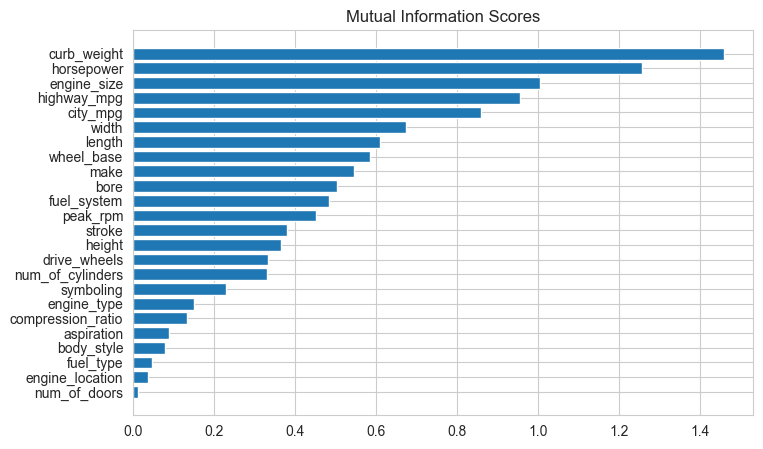

In [26]:
def plot_mi_scores(scores):
    scores=scores.sort_values(ascending =True)
    width=np.arange(len(scores))
    ticks=list(scores.index)
    plt.barh(width,scores)
    plt.yticks(width,ticks)
    plt.title("Mutual Information Scores")
plt.figure(dpi=100,figsize=(8,5))
plot_mi_scores(mi_scores)

#### As we might expect, the high-scoring curb_weight feature exhibits a strong relationship with price, the target.

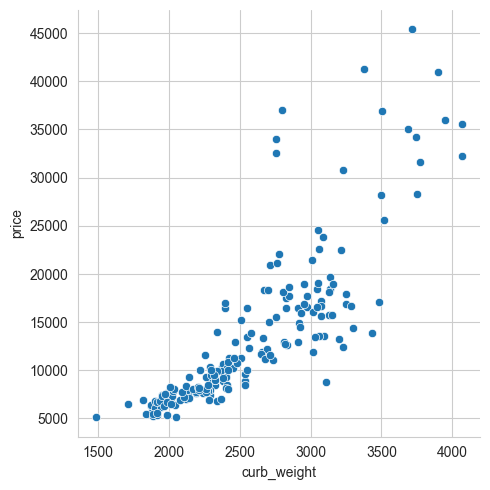

In [28]:
sns.relplot(x="curb_weight",y="price",data=df)

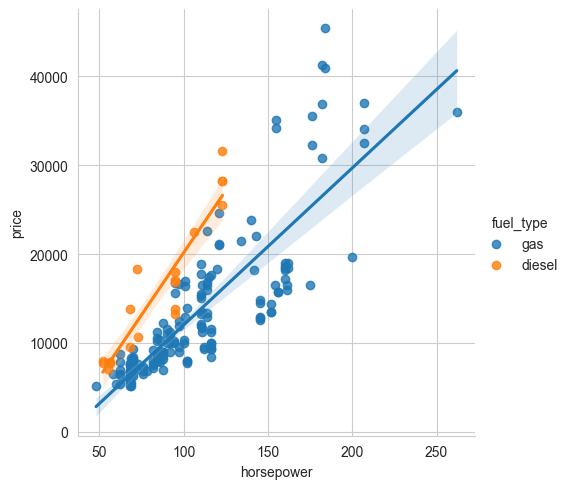

In [29]:
sns.lmplot(x="horsepower",y="price",hue="fuel_type",data=df)

## *LESSON 2:* ***Creating Features***

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
sns.set_style("whitegrid")
plt.rc("figure",autolayout=True)
plt.rc("axes",labelweight="bold",
       labelsize="large",
       titleweight="bold",
       titlesize=14,
       titlepad=10,
      )
accidents=pd.read_csv("accidents.csv")
autos=pd.read_csv("autos.csv")
concrete=pd.read_csv("concrete.csv")
customer=pd.read_csv("customer.csv")

##### STEP 1: *Mathematical Transforms*

In [33]:
# Create a new column called 'stroke_ratio' by dividing each car's stroke value by its bore value
# stroke_ratio = (length of piston travel) / (diameter of the cylinder)
autos["stroke_ratio"]=autos.stroke/autos.bore
# Display the first 5 rows of only the 'stroke', 'bore', and 'stroke_ratio' columns
autos[["stroke","bore","stroke_ratio"]].head()

,stroke,bore,stroke_ratio
0,2.68,3.47,0.772334
1,2.68,3.47,0.772334
2,3.47,2.68,1.294776
3,3.40,3.19,1.065831
4,3.40,3.19,1.065831


In [34]:
# Calculate the engine displacement for each car in the dataset
# Formula: π × (radius²) × stroke × number_of_cylinders
# where:
#   - bore = cylinder diameter
#   - radius = bore / 2
#   - stroke = distance the piston moves in one direction
#   - num_of_cylinders = total cylinders in the engine
# Units: if bore and stroke are in centimeters, displacement will be in cubic centimeters (cc)

autos['displacement']=(np.pi * ((0.5 *autos.bore)**2) * autos.stroke*autos.num_of_cylinders)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13604\1018992930.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(accidents.WindSpeed,shade=True,ax=axs[0])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13604\1018992930.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(accidents.LogWindSpeed,shade=True,ax=axs[1])


<Axes: xlabel='LogWindSpeed', ylabel='Density'>

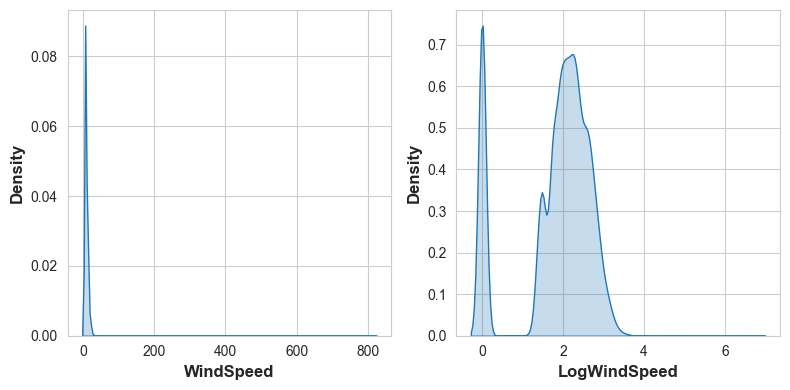

In [35]:
# If the feature has 0.0 values, use np.log1p (log(1+x)) instead of np.log
accidents['LogWindSpeed']=accidents.WindSpeed.apply(np.log1p)
# plot a comparison
fig,axs=plt.subplots(1,2,figsize=(8,4))
sns.kdeplot(accidents.WindSpeed,shade=True,ax=axs[0])
sns.kdeplot(accidents.LogWindSpeed,shade=True,ax=axs[1])

##### STEP 2: *Counts*

#### Features describing the presence or absence of something often come in sets, the set of risk factors for a disease, say. You can aggregate such features by creating a count

In [38]:
roadway_features=['Amenity','Bump','Crossing','GiveWay','Junction','NoExit','Railway','Roundabout','Station','Stop','TrafficCalming','TrafficSignal']
accidents['RoadwayFeatures']=accidents[roadway_features].sum(axis=1)
accidents[roadway_features + ['RoadwayFeatures']].head(10)

,Amenity,Bump,Crossing,GiveWay,Junction,NoExit,Railway,Roundabout,Station,Stop,TrafficCalming,TrafficSignal,RoadwayFeatures
0,False,False,False,False,False,False,False,False,False,False,False,False,0
1,False,False,False,False,False,False,False,False,False,False,False,False,0
2,False,False,False,False,False,False,False,False,False,False,False,False,0
3,False,False,False,False,False,False,False,False,False,False,False,False,0
4,False,False,False,False,False,False,False,False,False,False,False,False,0
5,False,False,False,False,True,False,False,False,False,False,False,False,1
6,False,False,False,False,False,False,False,False,False,False,False,False,0
7,False,False,True,False,False,False,False,False,False,False,False,True,2
8,False,False,True,False,False,False,False,False,False,False,False,True,2
9,False,False,False,False,False,False,False,False,False,False,False,False,0


In [39]:
#This will count how many components are in a formulation with the dataframe's built-in greater-than gt method
components=['Cement','BlastFurnaceSlag','FlyAsh','Water','Superplasticizer','CoarseAggregate','FineAggregate']
concrete['Components']=concrete[components].gt(0).sum(axis=1)
concrete[components + ['Components']].head(10)

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Components
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,5
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,5
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,5
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,5
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,5
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,5
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,5
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,5
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,4


##### STEP 3: *Building-Up and Breaking-Down features*

In [41]:
customer[['Type','Level']]=(customer['Policy'].str.split(" ",expand=True))
customer[['Policy','Type','Level']].head(10)

,Policy,Type,Level
0,Corporate L3,Corporate,L3
1,Personal L3,Personal,L3
2,Personal L3,Personal,L3
3,Corporate L2,Corporate,L2
4,Personal L1,Personal,L1
5,Personal L3,Personal,L3
6,Corporate L3,Corporate,L3
7,Corporate L3,Corporate,L3
8,Corporate L3,Corporate,L3
9,Special L2,Special,L2


In [42]:
autos["make_and_style"] = autos["make"] + "_" + autos["body_style"]
autos[["make", "body_style", "make_and_style"]].head()

,make,body_style,make_and_style
0,alfa-romero,convertible,alfa-romero_convertible
1,alfa-romero,convertible,alfa-romero_convertible
2,alfa-romero,hatchback,alfa-romero_hatchback
3,audi,sedan,audi_sedan
4,audi,sedan,audi_sedan


##### STEP 4: *Group Transform*

In [44]:
customer['AverageIncome']=(customer.groupby('State')#for each state
                           ['Income'].transform('mean'))#select the income and compute its mean
customer[['State','Income','AverageIncome']].head(10)

,State,Income,AverageIncome
0,Washington,56274,38122.733083
1,Arizona,0,37405.402231
2,Nevada,48767,38369.605442
3,California,0,37558.946667
4,Washington,43836,38122.733083
5,Oregon,62902,37557.283353
6,Oregon,55350,37557.283353
7,Arizona,0,37405.402231
8,Oregon,14072,37557.283353
9,Oregon,28812,37557.283353


In [45]:
# Calulating the frequency with ehich each state occurs in the dataset
customer['StateFreq']=(customer.groupby('State')['State'].transform('count')/customer.State.count())
customer[['State','StateFreq']].head(10)

,State,StateFreq
0,Washington,0.087366
1,Arizona,0.186446
2,Nevada,0.096562
3,California,0.344865
4,Washington,0.087366
5,Oregon,0.284760
6,Oregon,0.284760
7,Arizona,0.186446
8,Oregon,0.284760
9,Oregon,0.284760


In [46]:
# Create splits
df_train = customer.sample(frac=0.5)
df_valid = customer.drop(df_train.index)

# Create the average claim amount by coverage type, on the training set
df_train["AverageClaim"] = df_train.groupby("Coverage")["ClaimAmount"].transform("mean")

# Merge the values into the validation set
df_valid = df_valid.merge(
    df_train[["Coverage", "AverageClaim"]].drop_duplicates(),
    on="Coverage",
    how="left",
)

df_valid[["Coverage", "AverageClaim"]].head(10)

,Coverage,AverageClaim
0,Basic,380.203345
1,Basic,380.203345
2,Basic,380.203345
3,Premium,640.126820
4,Extended,474.838305
5,Premium,640.126820
6,Basic,380.203345
7,Basic,380.203345
8,Basic,380.203345
9,Extended,474.838305


## LESSON3: ***Clustering With K-means***

#### *Clustering simply means the assigning of data points to groups based upon how similar the points are to each other. A **clustering algorithm** makes "birds of a feather flock together," so to speak.*

### *Example:*

In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
sns.set_style("whitegrid")
plt.rc("figure",autolayout=True)
plt.rc("axes",labelweight="bold",labelsize="large",titleweight="bold",titlesize=14,titlepad=10,)
df=pd.read_csv("housing.csv")
X=df.loc[:,['MedInc','Latitude','Longitude']]
X.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


In [51]:
pip install --upgrade scikit-learn numpy threadpoolctl


  Using cached numpy-2.3.2-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.3.2-cp312-cp312-win_amd64.whl (12.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.3.2 which is incompatible.
numba 0.59.1 requires numpy<1.27,>=1.22, but you have numpy 2.3.2 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.3.2 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.3.2 which is incompatible.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 25.0 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 5.29.3 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.3.2 which is incompatible.


In [52]:
# Create cluster feature
kmeans = KMeans(n_clusters=6)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")

X.head()

,MedInc,Latitude,Longitude,Cluster
0,8.3252,37.88,-122.23,0
1,8.3014,37.86,-122.22,0
2,7.2574,37.85,-122.24,0
3,5.6431,37.85,-122.25,0
4,3.8462,37.85,-122.25,5


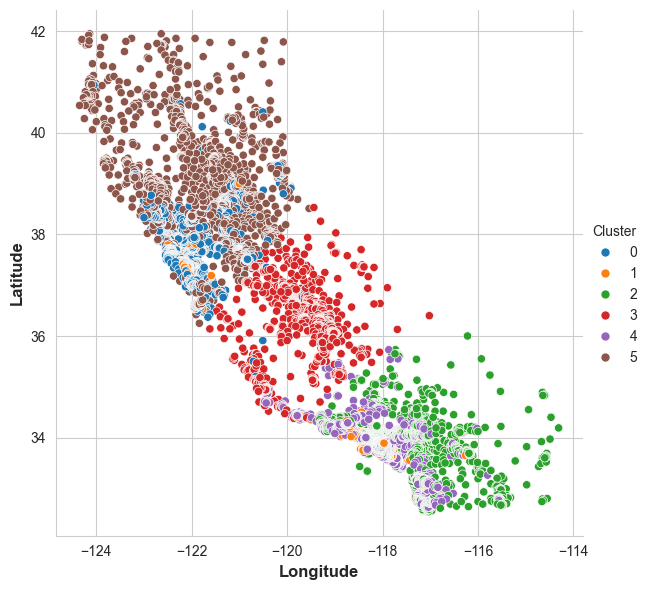

In [53]:
sns.relplot(x='Longitude',y='Latitude',hue='Cluster',data=X,height=6,);

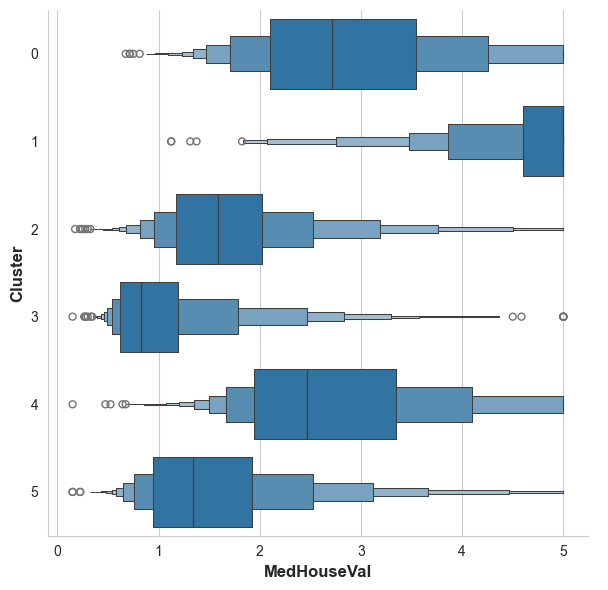

In [54]:
X['MedHouseVal']=df['MedHouseVal']
sns.catplot(x='MedHouseVal',y='Cluster',data=X,kind='boxen',height=6);

## *Sample Practice*

### ***Scaling features***
##### Consider the following sets of features. For each, decide whether:

###### .they definitely should be rescaled,
###### .they definitely should not be rescaled, or
###### .either might be reasonable
###### Features:

###### Latitude and Longitude of cities in California
###### Lot Area and Living Area of houses in Ames, Iowa
###### Number of Doors and Horsepower of a 1989 model car

In [57]:
!pip install xgboost


### *STEP 1:* ***Load the necessary environment***  

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

# Set Matplotlib defaults
sns.set_style("whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


def score_dataset(X, y, model=XGBRegressor()):
    # Label encoding for categoricals
    for colname in X.select_dtypes(["category", "object"]):
        X[colname], _ = X[colname].factorize()
    # Metric for Housing competition is RMSLE (Root Mean Squared Log Error)
    score = cross_val_score(
        model, X, y, cv=5, scoring="neg_mean_squared_log_error",
    )
    score = -1 * score.mean()
    score = np.sqrt(score)
    return score


# Prepare data
df = pd.read_csv("ames.csv")

#### *STEP 2:* ***Create a Feature of Cluster Labels***

#### Creating a k-means clustering with the following parameters:

#### **.** *features: LotArea, TotalBsmtSF, FirstFlrSF, SecondFlrSF,GrLivArea*
#### **.** *number of clusters: 10*
#### **.** *iterations: 10*

In [62]:
X=df.copy()
y=X.pop('SalePrice')
#Defining the list of featres to be used for the clustering
features=[
    "LotArea",
    "TotalBsmtSF",
    "FirstFlrSF",
    "SecondFlrSF",
    "GrLivArea",
]
# Standardize the features
X_scaled=X.loc[:,features]
X_scaled=(X_scaled - X_scaled.mean(axis=0))/X_scaled.std(axis=0)
# Fit the KMeans model to X_scaled and create the cluster labels
kmeans = KMeans(n_clusters=10,n_init=10, random_state=0)
X["Cluster"] = kmeans.fit_predict(X_scaled)



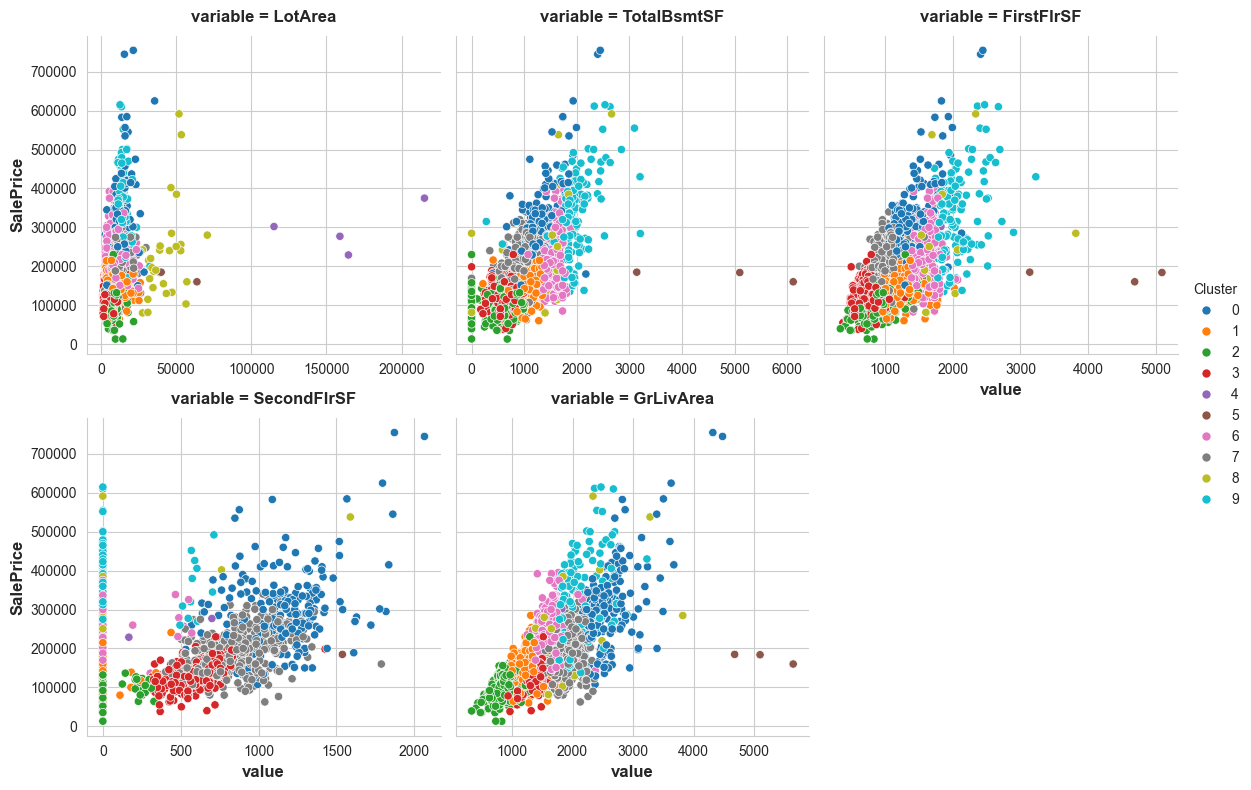

In [63]:
Xy = X.copy()
Xy["Cluster"] = Xy.Cluster.astype("category")
Xy["SalePrice"] = y
sns.relplot(
    x="value", y="SalePrice", hue="Cluster", col="variable",
    height=4, aspect=1, facet_kws={'sharex': False}, col_wrap=3,
    data=Xy.melt(
        value_vars=features, id_vars=["SalePrice", "Cluster"],
    ),
);


### *STEP 3:* ***Cluster-Distance Features***

In [65]:
kmeans = KMeans(n_clusters=10, n_init=10, random_state=0)


#  Create the cluster-distance features using `fit_transform`
X_cd = kmeans.fit_transform(X_scaled)

# Label features and join to dataset
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X = X.join(X_cd)



## **LESSON 4:** ***Principal Component Analysis***

#### ****Principal Component Analysis*** (PCA) is a dimensionality reduction technique used in data analysis and machine learning. Let me break it down clearly:

#### *Example:*

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_selection import mutual_info_regression


sns.set_style("whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


df = pd.read_csv("autos.csv")

In [70]:
features = ["highway_mpg", "engine_size", "horsepower", "curb_weight"]

X = df.copy()
y = X.pop('price')
X = X.loc[:, features]

# Standardize
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

In [71]:
from sklearn.decomposition import PCA

# Create principal components
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Convert to dataframe
component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca = pd.DataFrame(X_pca, columns=component_names)

X_pca.head()

,PC1,PC2,PC3,PC4
0,0.382486,-0.400222,0.124122,0.169539
1,0.382486,-0.400222,0.124122,0.169539
2,1.550890,-0.107175,0.598361,-0.256081
3,-0.408859,-0.425947,0.243335,0.013920
4,1.132749,-0.814565,-0.202885,0.224138


In [72]:
loadings = pd.DataFrame(
    pca.components_.T,  # transpose the matrix of loadings
    columns=component_names,  # so the columns are the principal components
    index=X.columns,  # and the rows are the original features
)
loadings

,PC1,PC2,PC3,PC4
highway_mpg,-0.492347,0.770892,0.070142,-0.397996
engine_size,0.503859,0.626709,0.019960,0.594107
horsepower,0.500448,0.013788,0.731093,-0.463534
curb_weight,0.503262,0.113008,-0.678369,-0.523232


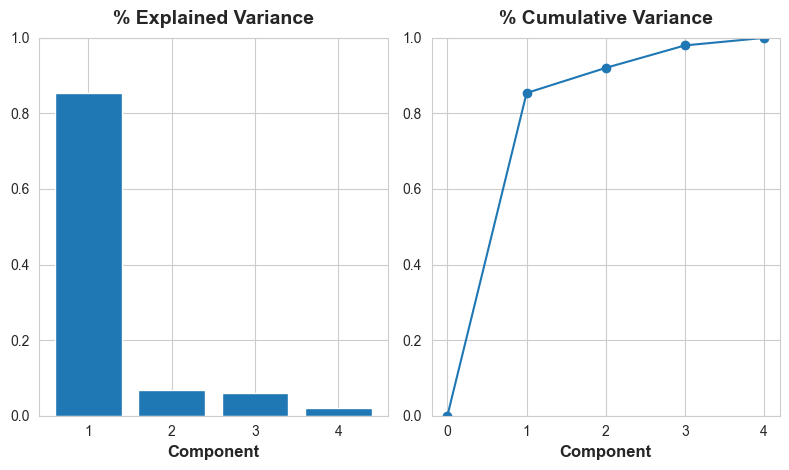

In [73]:
# Look at explained variance
plot_variance(pca);

In [74]:
mi_scores = make_mi_scores(X_pca, y, discrete_features=False)
mi_scores

PC1    1.014442
PC2    0.379189
PC3    0.305915
PC4    0.203300
Name: MI Scores, dtype: float64

In [75]:
# Show dataframe sorted by PC3
idx = X_pca["PC3"].sort_values(ascending=False).index
cols = ["make", "body_style", "horsepower", "curb_weight"]
df.loc[idx, cols]

,make,body_style,horsepower,curb_weight
118,porsche,hardtop,207,2756
117,porsche,hardtop,207,2756
119,porsche,convertible,207,2800
45,jaguar,sedan,262,3950
96,nissan,hatchback,200,3139
...,...,...,...,...
59,mercedes-benz,wagon,123,3750
61,mercedes-benz,sedan,123,3770
101,peugot,wagon,95,3430
105,peugot,wagon,95,3485


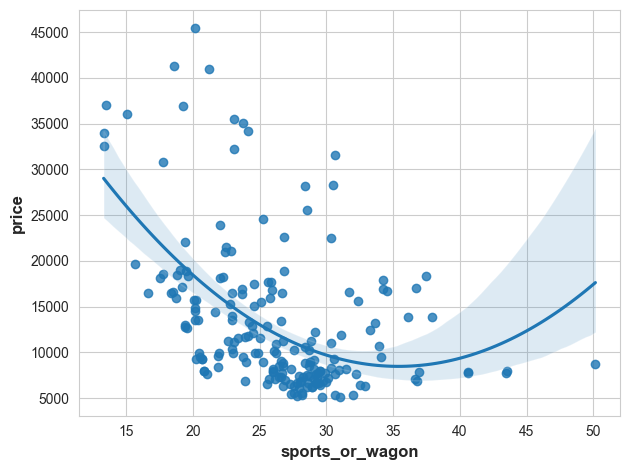

In [76]:
df["sports_or_wagon"] = X.curb_weight / X.horsepower
sns.regplot(x="sports_or_wagon", y='price', data=df, order=2);

### ***Sample Exercise***

#### **Load Necessary Libraries and Set-up**

In [79]:
# Setup feedback system


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

# Set Matplotlib defaults
sns.set_style("whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)


def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings


def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs


def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def score_dataset(X, y, model=XGBRegressor()):
    # Label encoding for categoricals
    for colname in X.select_dtypes(["category", "object"]):
        X[colname], _ = X[colname].factorize()
    # Metric for Housing competition is RMSLE (Root Mean Squared Log Error)
    score = cross_val_score(
        model, X, y, cv=5, scoring="neg_mean_squared_log_error",
    )
    score = -1 * score.mean()
    score = np.sqrt(score)
    return score


df = pd.read_csv("ames.csv")

In [80]:
features = [
    "GarageArea",
    "YearRemodAdd",
    "TotalBsmtSF",
    "GrLivArea",
]

print("Correlation with SalePrice:\n")
print(df[features].corrwith(df.SalePrice))

Correlation with SalePrice:

GarageArea      0.640138
YearRemodAdd    0.532974
TotalBsmtSF     0.632529
GrLivArea       0.706780
dtype: float64


In [81]:
X = df.copy()
y = X.pop("SalePrice")
X = X.loc[:, features]

# `apply_pca`, defined above, reproduces the code from the tutorial
pca, X_pca, loadings = apply_pca(X)
print(loadings)


                   PC1       PC2       PC3       PC4
GarageArea    0.541229 -0.102375 -0.038470  0.833733
YearRemodAdd  0.427077  0.886612 -0.049062 -0.170639
TotalBsmtSF   0.510076 -0.360778 -0.666836 -0.406192
GrLivArea     0.514294 -0.270700  0.742592 -0.332837


#### *STEP 1:* ***Interpret Component Loadings***

#### *STEP 2:* ***Create New Features***

In [84]:
X = df.copy()
y = X.pop("SalePrice")

# YOUR CODE HERE: Add new features to X.
X["Feature1"] = X.GrLivArea + X.TotalBsmtSF
X["Feature2"] = X.YearRemodAdd * X.TotalBsmtSF

score = score_dataset(X, y)
print(f"Your score: {score:.5f} RMSLE")


Your score: 0.13792 RMSLE


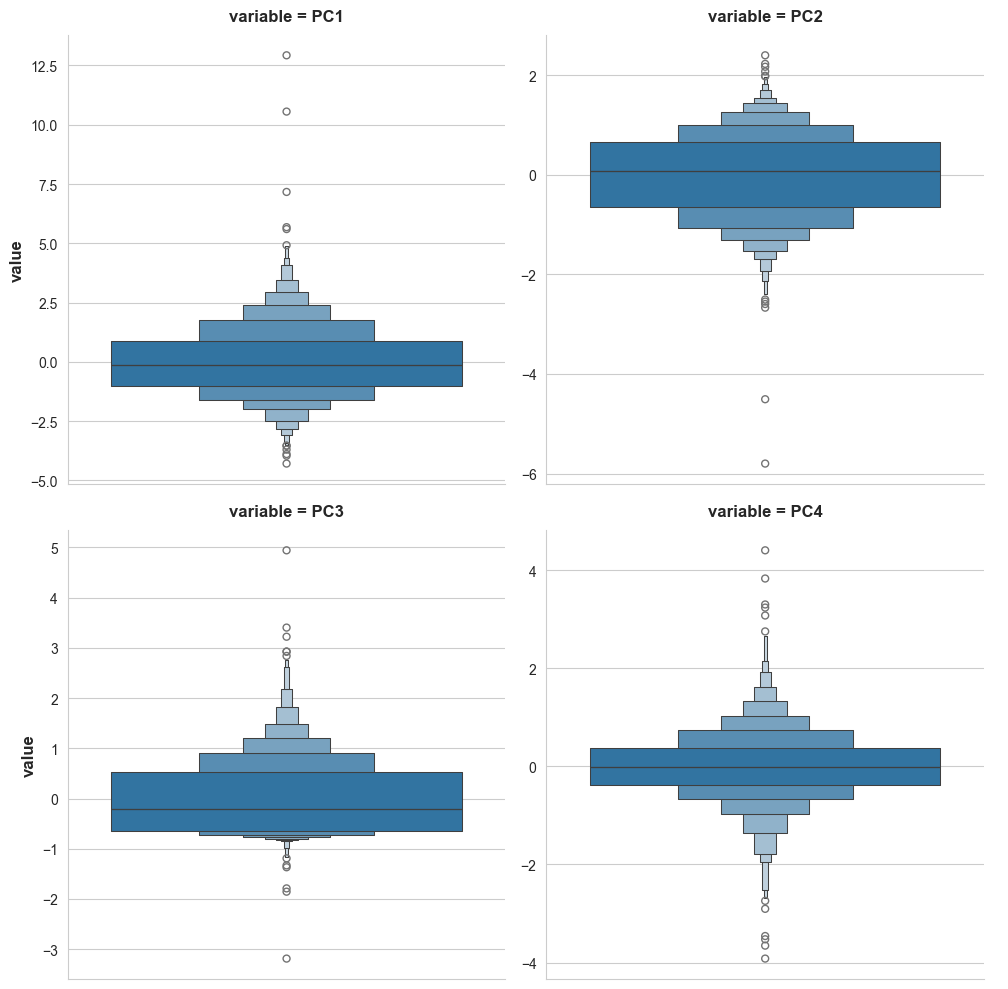

In [85]:
sns.catplot(
    y="value",
    col="variable",
    data=X_pca.melt(),
    kind='boxen',
    sharey=False,
    col_wrap=2,
);

In [86]:
# You can change PC1 to PC2, PC3, or PC4
component = "PC1"

idx = X_pca[component].sort_values(ascending=False).index
df.loc[idx, ["SalePrice", "Neighborhood", "SaleCondition"] + features]

,SalePrice,Neighborhood,SaleCondition,GarageArea,YearRemodAdd,TotalBsmtSF,GrLivArea
1498,160000,Edwards,Partial,1418.0,2008,6110.0,5642.0
2180,183850,Edwards,Partial,1154.0,2009,5095.0,5095.0
2181,184750,Edwards,Partial,884.0,2008,3138.0,4676.0
1760,745000,Northridge,Abnorml,813.0,1996,2396.0,4476.0
1767,755000,Northridge,Normal,832.0,1995,2444.0,4316.0
...,...,...,...,...,...,...,...
662,59000,Old_Town,Normal,0.0,1950,416.0,599.0
2679,80500,Brookside,Normal,0.0,1950,0.0,912.0
2879,51689,Iowa_DOT_and_Rail_Road,Abnorml,0.0,1950,0.0,729.0
780,63900,Sawyer,Normal,0.0,1950,0.0,660.0


## *LESSON 5:* ***Target Encoding***

###### A ***target encoding*** is any kind of encoding that replaces a feature's categories with some number derived from the target.

In [89]:
autos["make_encoded"] = autos.groupby("make")["price"].transform("mean")

autos[["make", "price", "make_encoded"]].head(10)

,make,price,make_encoded
0,alfa-romero,13495,15498.333333
1,alfa-romero,16500,15498.333333
2,alfa-romero,16500,15498.333333
3,audi,13950,17859.166667
4,audi,17450,17859.166667
5,audi,15250,17859.166667
6,audi,17710,17859.166667
7,audi,18920,17859.166667
8,audi,23875,17859.166667
9,bmw,16430,26118.750000


##### A solution to these problems is to add smoothing. The idea is to blend the in-category average with the overall average. Rare categories get less weight on their category average, while missing categories just get the overall average

### *Example:* 

In [92]:
import warnings

sns.set_style("whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
warnings.filterwarnings('ignore')


df = pd.read_csv("movielens1m.csv")
df = df.astype(np.uint8, errors='ignore') # reduce memory footprint
print("Number of Unique Zipcodes: {}".format(df["Zipcode"].nunique()))


Number of Unique Zipcodes: 3439


In [93]:
X = df.copy()
y = X.pop('Rating')

X_encode = X.sample(frac=0.25)
y_encode = y[X_encode.index]
X_pretrain = X.drop(X_encode.index)
y_train = y[X_pretrain.index]

In [94]:
!pip install category_encoders --quiet


In [95]:
!pip install --upgrade scipy statsmodels category_encoders


In [96]:
from category_encoders import MEstimateEncoder

# Create the encoder instance. Choose m to control noise.
encoder = MEstimateEncoder(cols=["Zipcode"], m=5.0)

# Fit the encoder on the encoding split.
encoder.fit(X_encode, y_encode)

# Encode the Zipcode column to create the final training data
X_train = encoder.transform(X_pretrain)

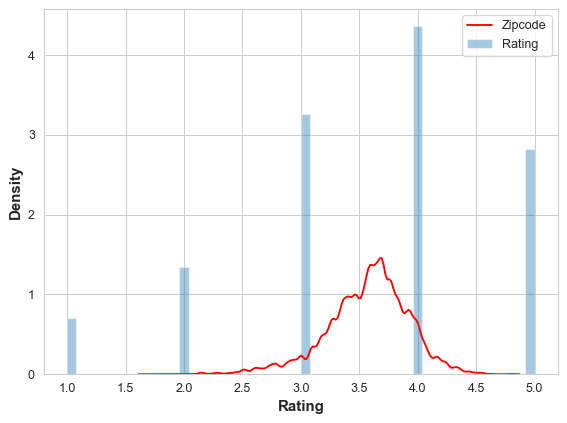

In [97]:
plt.figure(dpi=90)
ax = sns.distplot(y, kde=False, norm_hist=True)
ax = sns.kdeplot(X_train.Zipcode, color='r', ax=ax)
ax.set_xlabel("Rating")
ax.legend(labels=['Zipcode', 'Rating']);

### *Sample Exercise*

#### Getting the necessary libraries and set-up

In [156]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
from category_encoders import MEstimateEncoder
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

# Set Matplotlib defaults
sns.set_style("whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
warnings.filterwarnings('ignore')


def score_dataset(X, y, model=XGBRegressor()):
    # Label encoding for categoricals
    for colname in X.select_dtypes(["category", "object"]):
        X[colname], _ = X[colname].factorize()
    # Metric for Housing competition is RMSLE (Root Mean Squared Log Error)
    score = cross_val_score(
        model, X, y, cv=5, scoring="neg_mean_squared_log_error",
    )
    score = -1 * score.mean()
    score = np.sqrt(score)
    return score


df = pd.read_csv("ames.csv")

In [163]:
df.select_dtypes(["object"]).nunique()

MSSubClass       16
MSZoning          7
Street            2
Alley             3
LotShape          4
LandContour       4
Utilities         3
LotConfig         5
LandSlope         3
Neighborhood     28
Condition1        9
Condition2        8
BldgType          5
HouseStyle        8
OverallQual      10
OverallCond       9
RoofStyle         6
RoofMatl          8
Exterior1st      16
Exterior2nd      17
MasVnrType        4
ExterQual         4
ExterCond         5
Foundation        6
BsmtQual          6
BsmtCond          6
BsmtExposure      5
BsmtFinType1      7
BsmtFinType2      7
Heating           6
HeatingQC         5
CentralAir        2
Electrical        6
KitchenQual       5
Functional        8
FireplaceQu       6
GarageType        7
GarageFinish      4
GarageQual        6
GarageCond        6
PavedDrive        3
PoolQC            5
Fence             5
MiscFeature       5
SaleType         10
SaleCondition     6
dtype: int64

#### *STEP1:* ***Choose Feature For Encoding***

In [166]:
# Encoding split
X_encode = df.sample(frac=0.20, random_state=0)
y_encode = X_encode.pop("SalePrice")

# Training split
X_pretrain = df.drop(X_encode.index)
y_train = X_pretrain.pop("SalePrice")

#### *STEP2:* ***Apply M-Estimate Encoding***

In [169]:
#Create the MEstimateEncoder
# Choose a set of features to encode and a value for m
encoder = MEstimateEncoder(
    cols=["Neighborhood"],
    m=1.0,
)



# Fit the encoder on the encoding split
encoder.fit(X_encode,y_encode)
# Encode the training split
X_train = encoder.transform(X_pretrain, y_train)


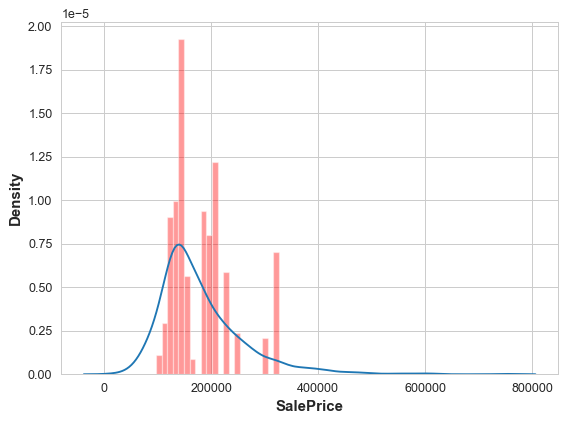

In [171]:
feature = encoder.cols

plt.figure(dpi=90)
ax = sns.distplot(y_train, kde=True, hist=False)
ax = sns.distplot(X_train[feature], color='r', ax=ax, hist=True, kde=False, norm_hist=True)
ax.set_xlabel("SalePrice");

In [173]:
X = df.copy()
y = X.pop("SalePrice")
score_base = score_dataset(X, y)
score_new = score_dataset(X_train, y_train)

print(f"Baseline Score: {score_base:.4f} RMSLE")
print(f"Score with Encoding: {score_new:.4f} RMSLE")

Baseline Score: 0.1434 RMSLE
Score with Encoding: 0.1434 RMSLE


In [175]:
# Trying to  experiment with the smoothing parameter m
# Try 0, 1, 5, 50
m = 0

X = df.copy()
y = X.pop('SalePrice')

# Create an uninformative feature
X["Count"] = range(len(X))
X["Count"][1] = 0  # actually need one duplicate value to circumvent error-checking in MEstimateEncoder

# fit and transform on the same dataset
encoder = MEstimateEncoder(cols="Count", m=m)
X = encoder.fit_transform(X, y)

# Results
score =  score_dataset(X, y)
print(f"Score: {score:.4f} RMSLE")

Score: 0.0375 RMSLE
